# 🧠 Why Use CNN Instead of ANN for Grid-Based Reinforcement Learning

In grid-world environments (e.g., Hamiltonian cycle over a grid), the choice of network architecture directly affects performance, generalization, and training efficiency. This section explains **why CNNs are preferred over traditional ANNs**, including architectural differences, parameter comparisons, and generalization benefits.

---
## 🧩 Robustness to Grid Size Changes

A major advantage of CNNs is that they can handle different input grid sizes **without needing to reconfigure the architecture**. This is crucial in our Hamiltonian Cycle setup where we scale from small (2×2) to larger (6×6 or 10×10) grids.

### 🔄 ANN Limitation:
- ANN requires the input to be flattened to a 1D vector.
- Grid size 4×4 → Input: 16 nodes  
  Grid size 6×6 → Input: 36 nodes
- So the **input layer shape changes** with the grid size.
- This means:
  - You need **new weight matrices** for each size.
  - You **cannot reuse learned policies** directly.
  - **Transfer learning is harder.**

### 🔄 CNN Advantage:
- CNNs take **2D input** with height × width × channels.
- Changing from 4×4 to 6×6 grid only changes the **input dimensions**, **not the kernel size or layer structure**.
- You can reuse the **same CNN layers and filters** across grid sizes.
- Enables **seamless transfer learning** and **scalability**.

#### Example:

| Grid Size | ANN Input Size | CNN Input Shape | Retraining Needed |
|-----------|----------------|------------------|-------------------|
| 2×2       | 4              | (1×2×2)          | Yes (ANN), No (CNN)|
| 4×4       | 16             | (1×4×4)          | Yes (ANN), No (CNN)|
| 6×6       | 36             | (1×6×6)          | Yes (ANN), No (CNN)|

> ✅ **CNNs generalize across different input sizes without changing the model.**

---


## 🔍 Architectural Differences: CNN vs ANN

| Feature                      | ANN (Artificial Neural Network)        | CNN (Convolutional Neural Network)          |
|-----------------------------|----------------------------------------|---------------------------------------------|
| **Input Format**            | Requires flattening (2D → 1D)          | Accepts 2D grid directly                    |
| **Spatial Awareness**       | Lost due to flattening                 | Preserved via convolutional filters         |
| **Scalability to Grid Size**| Poor – requires architectural changes  | Excellent – filters adapt to grid size      |
| **Parameter Count**         | High for large input sizes             | Lower due to weight sharing                 |
| **Overfitting Risk**        | Higher                                 | Lower due to local receptive fields         |
| **Training Time**           | Slower on large inputs                 | Faster and more efficient                   |

---

## 📉 Reduced Parameters with CNN

CNNs use **convolutional kernels** which slide across the grid, sharing weights. This leads to:

- Fewer parameters to train.
- Better generalization across grid sizes.
- Efficient reuse of learned features (like corners, paths).

### Example:
- ANN for a `6x6` grid (36 inputs) with 2 hidden layers might require **>10,000 weights**.
- CNN with `2 conv layers` and 1 FC layer can achieve similar/better performance with **<5,000 weights**.

---

## 🧠 Generalization Across Grid Sizes

One of the most powerful benefits of CNNs: **grid-size independence**.

- **ANNs**: Input size = number of neurons. Changing the grid from `2x2` to `6x6` means retraining with a new input layer.
- **CNNs**: Convolutions operate on **local features**, regardless of grid dimensions. Same model can transfer from `2x2` → `4x4` → `6x6`.

---

## 🔄 High-Level Flowchart of CNN in Grid RL

```plaintext
Grid State (NxN)
     ↓
 Convolution Layer 1
     ↓
 Convolution Layer 2
     ↓
 Flatten
     ↓
 Fully Connected Layer
     ↓
 Action Values (Q-values)


# 🧠 Model Architecture and Reward Strategy for Hamiltonian Cycle Learning

---

## 🏗️ Neural Network Architecture

We use a **CNN-based Deep Q-Network (DQN)** for learning Hamiltonian cycles in a grid-based Snake-style environment. The model architecture is as follows:

### 📌 DQNCNN (Grid-Conditioned)

- **Input:** `grid_size × grid_size` matrix representing the game state  
- **Layers:**
  - `Conv2D (1 → 32 filters, kernel=3, padding=1)` → ReLU
  - `Conv2D (32 → 64 filters, kernel=3, padding=1)` → ReLU
  - `Flatten`
  - `Fully Connected (64 × grid_size² → 256)` → ReLU
  - `Fully Connected (256 → 4)` → Outputs Q-values for 4 actions (up, down, left, right)

- **Device:** CUDA or CPU depending on availability

---

## 🎯 Dynamic Reward System

The reward strategy is carefully designed to encourage two key objectives:
1. **Cover all cells without revisiting**
2. **Return to the start to complete the cycle**

| Situation                                           | Reward         | Description                                                   |
|----------------------------------------------------|----------------|---------------------------------------------------------------|
| Move to unvisited cell                             | `+100`         | Encourages exploration and grid coverage                      |
| Revisiting any cell (loop collision)               | `-1000`        | Penalizes loops                                               |
| Move out of bounds                                 | `-1000`        | Penalizes invalid moves                                       |
| Return to start (0,0) **after visiting all cells** | `+10000`       | Huge bonus for completing Hamiltonian cycle                   |
| Return to start **without full coverage**          | `1000 * (visited / total)` | Scaled reward for partial completion                     |

> 🔁 This **multi-phase reward** helps shape the behavior towards both **complete coverage** and **cycle formation**.

---

## ⚙️ Hyperparameters

| Parameter             | Value       | Description                                 |
|----------------------|-------------|---------------------------------------------|
| `GRID_SIZE`          | 2 (initial) | Grid dimension (to be scaled via curriculum)|
| `EPSILON`            | 100         | Exploration probability (decays over time)  |
| `EPSILON_DECAY`      | 0.995       | Rate at which exploration reduces           |
| `EPSILON_MIN`        | 0.1         | Minimum exploration threshold               |
| `GAMMA`              | 0.9         | Discount factor for future rewards          |
| `LEARNING_RATE`      | 0.01        | Optimizer learning rate                     |
| `BATCH_SIZE`         | 64          | Size of replay memory batch                 |
| `MEMORY_SIZE`        | 2000        | Size of the experience replay buffer        |
| `EPISODES`           | 1500        | Training episodes per grid size             |

---

## ♻️ Transfer Learning Support

- The agent loads weights from a **previously trained base model** (`base_model3.pth`) if available
- During transfer, only layers with matching shapes are updated
- This allows curriculum learning from **2×2 → 4×4 → 6×6** grids

---

## 📈 Visualization

- The best path learned is visualized using `matplotlib`, with:
  - Blue arrows indicating direction
  - Green circle as start
  - Red circle as end

---

## 🧪 Next Steps

- Confirm convergence on 2×2 grid (where only valid solution is a cycle)
- Gradually increase to 4×4 and beyond while maintaining learned behavior

---


# 🧱 System Overview: Block Diagram & CNN Rationale

---

## 📊 Block Diagram: Hamiltonian Cycle Solver Using DQN

```plaintext
+------------------+
|  Environment     | ←── Grid-based Snake Game (NxN)
|  (NxN Grid)      |
+------------------+
         │
         ▼
+------------------+
|  State Encoding  | ←── Grid is encoded as a single-channel NxN image
|  (1×N×N Tensor)  |
+------------------+
         │
         ▼
+---------------------+
|  CNN-based Q-Network| ←── Learns Q-values for each action
|  - Conv2D Layers    |
|  - Fully Connected  |
+---------------------+
         │
         ▼
+------------------+
|  Action Selection | ←── ε-greedy policy
+------------------+
         │
         ▼
+------------------+
|  Environment Step | ←── Agent performs action and updates grid
+------------------+
         │
         ▼
+------------------+
|  Reward Function  | ←── Reward based on visit history and cycle completion
+------------------+
         │
         ▼
+------------------+
|  Experience Replay|
|  + DQN Training   |
+------------------+
         ▲
         └───────── Loop back for next episode


Using device: cuda
Training from scratch.
Model saved to base_model3.pth
Episode 1: Reward = -1000, Unique Cells = 1
Episode 2: Reward = -1000, Unique Cells = 1
Episode 3: Reward = -1000, Unique Cells = 1
Episode 4: Reward = -900, Unique Cells = 2
Episode 5: Reward = -800, Unique Cells = 3
Episode 6: Reward = -900, Unique Cells = 2
total : 600.0 max_reward : 600.0
Episode 7: Reward = 600.0, Unique Cells = 2
Episode 8: Reward = -900, Unique Cells = 2
Episode 9: Reward = -900, Unique Cells = 2
Episode 10: Reward = -1000, Unique Cells = 1
Episode 11: Reward = -1000, Unique Cells = 1
Episode 12: Reward = -1000, Unique Cells = 1
Episode 13: Reward = 600.0, Unique Cells = 2
Episode 14: Reward = -1000, Unique Cells = 1
Episode 15: Reward = 600.0, Unique Cells = 2
Episode 16: Reward = 600.0, Unique Cells = 2
Episode 17: Reward = -1000, Unique Cells = 1
Episode 18: Reward = -1000, Unique Cells = 1
Episode 19: Reward = -800, Unique Cells = 3
Episode 20: Reward = -1000, Unique Cells = 1
Episode 2

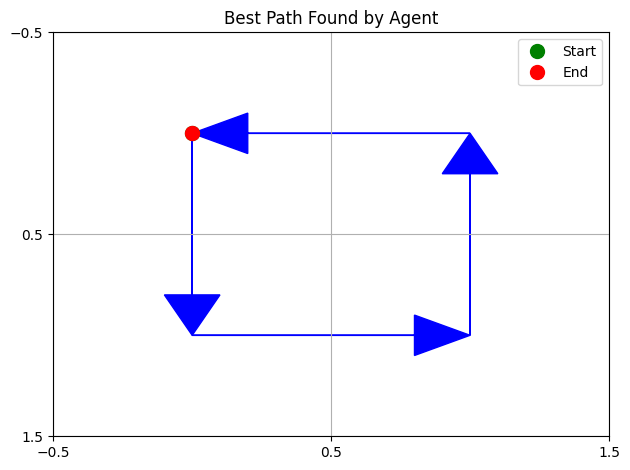

In [ ]:
import os
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

# Headless mode for Jupyter + disable pygame audio
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
pygame.display.init()
pygame.font.init()

# Parameters (modify this in Jupyter to change grid size)
GRID_SIZE = 2  # Change to 4 or 6 for transfer learning
BASE_MODEL_PATH = "base_model3.pth"

# Constants
WIDTH, HEIGHT = 600, 600
CELL_SIZE = WIDTH // GRID_SIZE
FPS = 60
BLACK, WHITE, RED, GREEN, BLUE = (0,0,0), (255,255,255), (255,0,0), (0,255,0), (0,0,255)

screen = pygame.Surface((WIDTH, HEIGHT))  # Dummy surface
clock = pygame.time.Clock()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DQNCNN(nn.Module):
    def __init__(self, grid_size, output_dim):
        super(DQNCNN, self).__init__()
        self.grid_size = grid_size
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * grid_size * grid_size, 256)
        self.fc2 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, self.grid_size, self.grid_size)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, grid_size, action_dim, base_model_path):
        self.grid_size = grid_size
        self.action_dim = action_dim
        self.epsilon = 100
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.1
        self.gamma = 0.9
        self.lr = 0.01
        self.batch_size = 64
        self.memory = deque(maxlen=2000)
        self.model = DQNCNN(grid_size, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Load or transfer
        if os.path.exists(base_model_path):
            print(f"Transferring weights from {base_model_path}...")
            pretrained_dict = torch.load(base_model_path, map_location=device, weights_only=True)
            model_dict = self.model.state_dict()
            transfer_dict = {k: v for k, v in pretrained_dict.items()
                             if k in model_dict and v.size() == model_dict[k].size()}
            model_dict.update(transfer_dict)
            self.model.load_state_dict(model_dict)
        else:
            print("Training from scratch.")

        self.model.train()

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = torch.FloatTensor([m[0] for m in minibatch]).to(device)
        actions = torch.LongTensor([m[1] for m in minibatch]).to(device)
        rewards = torch.FloatTensor([m[2] for m in minibatch]).to(device)
        next_states = torch.FloatTensor([m[3] for m in minibatch]).to(device)
        dones = torch.BoolTensor([m[4] for m in minibatch]).to(device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (~dones) * self.gamma * next_q

        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

def reset_game():
    grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    x, y = 0, 0
    grid[y][x] = 3
    return grid, x, y

def draw_grid(grid):
    screen.fill(BLACK)
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = grid[y][x]
            color = WHITE if val == 0 else GREEN if val == 1 else RED if val == 2 else BLUE
            pygame.draw.rect(screen, color, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE), 1)

def visualize_best_path_arrows(best_path):
    x, y = 0, 0
    path_coords = [(x, y)]
    for action in best_path:
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = x + dx, y + dy
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            x, y = new_x, new_y
            path_coords.append((x, y))
        else:
            break
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True)
    ax.invert_yaxis()
    for i in range(len(path_coords) - 1):
        x0, y0 = path_coords[i]
        x1, y1 = path_coords[i + 1]
        dx, dy = x1 - x0, y1 - y0
        ax.arrow(x0, y0, dx * 0.8, dy * 0.8, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
    ax.plot(path_coords[0][0], path_coords[0][1], 'go', markersize=10, label='Start')
    ax.plot(path_coords[-1][0], path_coords[-1][1], 'ro', markersize=10, label='End')
    ax.legend()
    plt.title("Best Path Found by Agent")
    plt.tight_layout()
    plt.show()

# === TRAINING ===
agent = DQNAgent(GRID_SIZE, 4, BASE_MODEL_PATH)
best_path = []
max_reward = 0

for episode in range(1500):  # You can increase this
    grid, player_x, player_y = reset_game()
    grid[player_y][player_x] = 2
    visited = set()
    visited.add((player_x, player_y))
    done = False
    total_reward = 0
    path = []

    while not done:
        state = np.array(grid, dtype=np.float32)
        action = agent.act(state)
        path.append(action)
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = player_x + dx, player_y + dy
        if grid[player_y][player_x] == 2:
            grid[player_y][player_x] = 1
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            if new_y == 0 and new_x == 0 :
                if len(visited) == GRID_SIZE * GRID_SIZE:
                    reward = 10000
                else:
                    reward = 1000* (len(visited)/(GRID_SIZE * GRID_SIZE))
                done = True
            elif grid[new_y][new_x] in [1, 2]:
                reward = -1000
                done = True
            else:
                player_x, player_y = new_x, new_y
                grid[player_y][player_x] = 2
                visited.add((player_x, player_y))
                reward = 100
        else:
            reward = -1000
            done = True
        next_state = np.array(grid, dtype=np.float32)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        total_reward += reward


In [ ]:
        draw_grid(grid)
        clock.tick(FPS)

    if episode%100 == 0:
        agent.save(BASE_MODEL_PATH)
    if  total_reward > max_reward:
        max_reward = total_reward
        best_path = path[:]
        print(f"total : {total_reward} max_reward : {max_reward}")
        

    print(f"Episode {episode + 1}: Reward = {total_reward}, Unique Cells = {len(visited)}")

# Visualize best
visualize_best_path_arrows(best_path)


# 🧪 Training Progress and Next Steps

## ✅ 2×2 Grid: Success!
- The model was successfully trained on a **2×2** grid.
- It was able to learn and **form a Hamiltonian cycle**.
- This verifies that the agent can:
  - **Visit all grid cells exactly once**, and
  - **Return to the starting cell**, completing a cycle.

---

## 🚀 Next Step: Training on 4×4 Grid
- With the base model trained on a smaller grid, we now scale to a **4×4** grid.
- The learned behavior (cycle formation) from 2×2 is expected to **transfer and generalize** to the larger environment.
- Training on the 4×4 grid will test whether:
  - The model can still complete a Hamiltonian path.
  - The cycle completion logic learned at smaller scale adapts to larger grids.
- This **progressive training approach** allows better learning efficiency and path structure understanding.

---

📌 *Note: Transfer learning is enabled by reusing the CNN model weights from the 2×2 training phase.*


Using device: cuda
Transferring weights from base_model.pth...
Model saved to base_model.pth
Episode 1: Reward = -700, Unique Cells = 4
Episode 2: Reward = -1000, Unique Cells = 1
Episode 3: Reward = -1000, Unique Cells = 1
Episode 4: Reward = -1000, Unique Cells = 1
Episode 5: Reward = -1000, Unique Cells = 1
Episode 6: Reward = -1000, Unique Cells = 1
Episode 7: Reward = -600, Unique Cells = 5
Episode 8: Reward = -800, Unique Cells = 3
Episode 9: Reward = -1000, Unique Cells = 1
Episode 10: Reward = -500, Unique Cells = 6
Episode 11: Reward = -900, Unique Cells = 2
Episode 12: Reward = -900, Unique Cells = 2
Episode 13: Reward = -1000, Unique Cells = 1
Episode 14: Reward = -1000, Unique Cells = 1
Episode 15: Reward = -1000, Unique Cells = 1
Episode 16: Reward = -1000, Unique Cells = 1
Episode 17: Reward = -900, Unique Cells = 2
Episode 18: Reward = -1000, Unique Cells = 1
total : 225.0 max_reward : 225.0
Episode 19: Reward = 225.0, Unique Cells = 2
Episode 20: Reward = -1000, Unique 

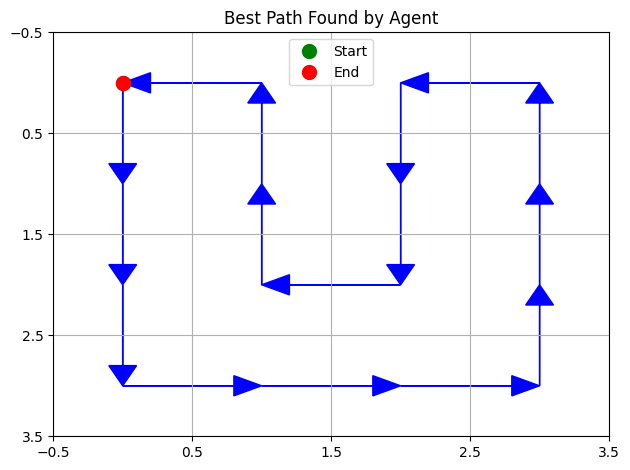

In [4]:
import os
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

# Headless mode for Jupyter + disable pygame audio
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
pygame.display.init()
pygame.font.init()

# Parameters (modify this in Jupyter to change grid size)
GRID_SIZE = 4  # Change to 4 or 6 for transfer learning
BASE_MODEL_PATH = "base_model.pth"

# Constants
WIDTH, HEIGHT = 600, 600
CELL_SIZE = WIDTH // GRID_SIZE
FPS = 60
BLACK, WHITE, RED, GREEN, BLUE = (0,0,0), (255,255,255), (255,0,0), (0,255,0), (0,0,255)

screen = pygame.Surface((WIDTH, HEIGHT))  # Dummy surface
clock = pygame.time.Clock()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DQNCNN(nn.Module):
    def __init__(self, grid_size, output_dim):
        super(DQNCNN, self).__init__()
        self.grid_size = grid_size
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * grid_size * grid_size, 256)
        self.fc2 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, self.grid_size, self.grid_size)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, grid_size, action_dim, base_model_path):
        self.grid_size = grid_size
        self.action_dim = action_dim
        self.epsilon = 1000
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.1
        self.gamma = 0.9
        self.lr = 0.01
        self.batch_size = 64
        self.memory = deque(maxlen=2000)
        self.model = DQNCNN(grid_size, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Load or transfer
        if os.path.exists(base_model_path):
            print(f"Transferring weights from {base_model_path}...")
            pretrained_dict = torch.load(base_model_path, map_location=device, weights_only=True)
            model_dict = self.model.state_dict()
            transfer_dict = {k: v for k, v in pretrained_dict.items()
                             if k in model_dict and v.size() == model_dict[k].size()}
            model_dict.update(transfer_dict)
            self.model.load_state_dict(model_dict)
        else:
            print("Training from scratch.")

        self.model.train()

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = torch.FloatTensor([m[0] for m in minibatch]).to(device)
        actions = torch.LongTensor([m[1] for m in minibatch]).to(device)
        rewards = torch.FloatTensor([m[2] for m in minibatch]).to(device)
        next_states = torch.FloatTensor([m[3] for m in minibatch]).to(device)
        dones = torch.BoolTensor([m[4] for m in minibatch]).to(device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (~dones) * self.gamma * next_q

        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

def reset_game():
    grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    x, y = 0, 0
    grid[y][x] = 3
    return grid, x, y

def draw_grid(grid):
    screen.fill(BLACK)
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = grid[y][x]
            color = WHITE if val == 0 else GREEN if val == 1 else RED if val == 2 else BLUE
            pygame.draw.rect(screen, color, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE), 1)

def visualize_best_path_arrows(best_path):
    x, y = 0, 0
    path_coords = [(x, y)]
    for action in best_path:
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = x + dx, y + dy
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            x, y = new_x, new_y
            path_coords.append((x, y))
        else:
            break
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True)
    ax.invert_yaxis()
    for i in range(len(path_coords) - 1):
        x0, y0 = path_coords[i]
        x1, y1 = path_coords[i + 1]
        dx, dy = x1 - x0, y1 - y0
        ax.arrow(x0, y0, dx * 0.8, dy * 0.8, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
    ax.plot(path_coords[0][0], path_coords[0][1], 'go', markersize=10, label='Start')
    ax.plot(path_coords[-1][0], path_coords[-1][1], 'ro', markersize=10, label='End')
    ax.legend()
    plt.title("Best Path Found by Agent")
    plt.tight_layout()
    plt.show()

# === TRAINING ===
agent = DQNAgent(GRID_SIZE, 4, BASE_MODEL_PATH)
best_path = []
max_reward = 0

for episode in range(10000):  # You can increase this
    grid, player_x, player_y = reset_game()
    grid[player_y][player_x] = 2
    visited = set()
    visited.add((player_x, player_y))
    done = False
    total_reward = 0
    path = []

    while not done:
        state = np.array(grid, dtype=np.float32)
        action = agent.act(state)
        path.append(action)
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = player_x + dx, player_y + dy
        if grid[player_y][player_x] == 2:
            grid[player_y][player_x] = 1
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            if new_y == 0 and new_x == 0 :
                if len(visited) == GRID_SIZE * GRID_SIZE:
                    reward = 10000
                else:
                    reward = 1000* (len(visited)/(GRID_SIZE * GRID_SIZE))
                done = True
            elif grid[new_y][new_x] in [1, 2]:
                reward = -1000
                done = True
            else:
                player_x, player_y = new_x, new_y
                grid[player_y][player_x] = 2
                visited.add((player_x, player_y))
                reward = 100
        else:
            reward = -1000
            done = True
        next_state = np.array(grid, dtype=np.float32)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        total_reward += reward
        draw_grid(grid)
        clock.tick(FPS)

    if episode%100 == 0:
        agent.save(BASE_MODEL_PATH)
    if  total_reward > max_reward:
        max_reward = total_reward
        best_path = path[:]
        print(f"total : {total_reward} max_reward : {max_reward}")
        

    print(f"Episode {episode + 1}: Reward = {total_reward}, Unique Cells = {len(visited)}")

# Visualize best
visualize_best_path_arrows(best_path)


# 🎉 4×4 Grid Training Completed

## ✅ Hamiltonian Cycle Formed on 4×4 Grid!
- The model, trained with transferred knowledge from the 2×2 grid, has successfully:
  - **Covered all 16 cells** without repetition.
  - **Returned to the starting cell**, forming a complete **Hamiltonian cycle**.
- This confirms the effectiveness of our **progressive training** and **CNN-based policy**.

---

## 📈 Next Step: Training on 6×6 Grid
- We now scale up to a **6×6** environment.
- The objective is to observe whether:
  - The model retains its ability to complete a Hamiltonian cycle.
  - Training efficiency is preserved via knowledge transfer.
- As grid complexity increases, this step will test the model’s **generalization** and **planning capabilities** on a larger state space.

---

📌 *We continue using the same CNN architecture to handle variable grid sizes seamlessly without needing to change input layer dimensions.*


Using device: cuda
Transferring weights from base_model.pth...
Model saved to base_model.pth
total : 155.55555555555554 max_reward : 155.55555555555554
Episode 1: Reward = 155.55555555555554, Unique Cells = 2
Episode 2: Reward = -1000, Unique Cells = 1
Episode 3: Reward = -1000, Unique Cells = 1
Episode 4: Reward = -900, Unique Cells = 2
Episode 5: Reward = -900, Unique Cells = 2
Episode 6: Reward = -500, Unique Cells = 6
Episode 7: Reward = -800, Unique Cells = 3
Episode 8: Reward = -1000, Unique Cells = 1
Episode 9: Reward = -700, Unique Cells = 4
Episode 10: Reward = 155.55555555555554, Unique Cells = 2
Episode 11: Reward = -900, Unique Cells = 2
Episode 12: Reward = -600, Unique Cells = 5
Episode 13: Reward = -600, Unique Cells = 5
Episode 14: Reward = -1000, Unique Cells = 1
Episode 15: Reward = -1000, Unique Cells = 1
Episode 16: Reward = -1000, Unique Cells = 1
Episode 17: Reward = -1000, Unique Cells = 1
Episode 18: Reward = -800, Unique Cells = 3
Episode 19: Reward = -1000, Un

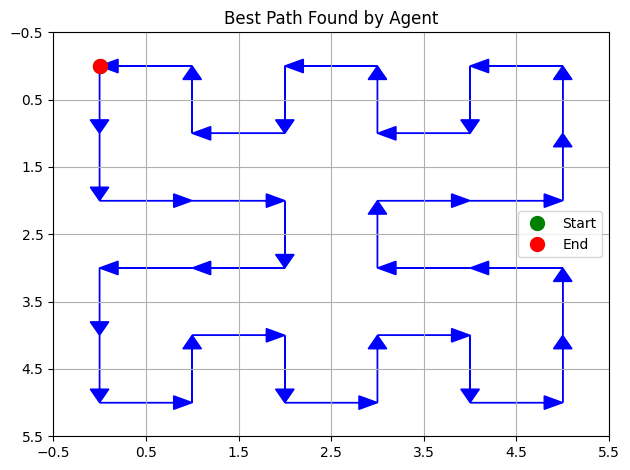

In [5]:
import os
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import matplotlib.pyplot as plt

# Headless mode for Jupyter + disable pygame audio
os.environ["SDL_VIDEODRIVER"] = "dummy"
os.environ["SDL_AUDIODRIVER"] = "dummy"
pygame.display.init()
pygame.font.init()

# Parameters (modify this in Jupyter to change grid size)
GRID_SIZE = 6  # Change to 4 or 6 for transfer learning
BASE_MODEL_PATH = "base_model.pth"

# Constants
WIDTH, HEIGHT = 600, 600
CELL_SIZE = WIDTH // GRID_SIZE
FPS = 60
BLACK, WHITE, RED, GREEN, BLUE = (0,0,0), (255,255,255), (255,0,0), (0,255,0), (0,0,255)

screen = pygame.Surface((WIDTH, HEIGHT))  # Dummy surface
clock = pygame.time.Clock()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class DQNCNN(nn.Module):
    def __init__(self, grid_size, output_dim):
        super(DQNCNN, self).__init__()
        self.grid_size = grid_size
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * grid_size * grid_size, 256)
        self.fc2 = nn.Linear(256, output_dim)

    def forward(self, x):
        x = x.view(-1, 1, self.grid_size, self.grid_size)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class DQNAgent:
    def __init__(self, grid_size, action_dim, base_model_path):
        self.grid_size = grid_size
        self.action_dim = action_dim
        self.epsilon = 10000
        self.epsilon_decay = 0.999
        self.epsilon_min = 0.1
        self.gamma = 0.9
        self.lr = 0.01
        self.batch_size = 64
        self.memory = deque(maxlen=2000)
        self.model = DQNCNN(grid_size, action_dim).to(device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        # Load or transfer
        if os.path.exists(base_model_path):
            print(f"Transferring weights from {base_model_path}...")
            pretrained_dict = torch.load(base_model_path, map_location=device, weights_only=True)
            model_dict = self.model.state_dict()
            transfer_dict = {k: v for k, v in pretrained_dict.items()
                             if k in model_dict and v.size() == model_dict[k].size()}
            model_dict.update(transfer_dict)
            self.model.load_state_dict(model_dict)
        else:
            print("Training from scratch.")

        self.model.train()

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.choice(range(self.action_dim))
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        minibatch = random.sample(self.memory, self.batch_size)
        states = torch.FloatTensor([m[0] for m in minibatch]).to(device)
        actions = torch.LongTensor([m[1] for m in minibatch]).to(device)
        rewards = torch.FloatTensor([m[2] for m in minibatch]).to(device)
        next_states = torch.FloatTensor([m[3] for m in minibatch]).to(device)
        dones = torch.BoolTensor([m[4] for m in minibatch]).to(device)

        current_q = self.model(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        next_q = self.model(next_states).max(1)[0]
        target_q = rewards + (~dones) * self.gamma * next_q

        loss = F.mse_loss(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Model saved to {path}")

def reset_game():
    grid = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    x, y = 0, 0
    grid[y][x] = 3
    return grid, x, y

def draw_grid(grid):
    screen.fill(BLACK)
    for y in range(GRID_SIZE):
        for x in range(GRID_SIZE):
            val = grid[y][x]
            color = WHITE if val == 0 else GREEN if val == 1 else RED if val == 2 else BLUE
            pygame.draw.rect(screen, color, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (x * CELL_SIZE, y * CELL_SIZE, CELL_SIZE, CELL_SIZE), 1)

def visualize_best_path_arrows(best_path):
    x, y = 0, 0
    path_coords = [(x, y)]
    for action in best_path:
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = x + dx, y + dy
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            x, y = new_x, new_y
            path_coords.append((x, y))
        else:
            break
    fig, ax = plt.subplots()
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(-0.5, GRID_SIZE - 0.5)
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1))
    ax.grid(True)
    ax.invert_yaxis()
    for i in range(len(path_coords) - 1):
        x0, y0 = path_coords[i]
        x1, y1 = path_coords[i + 1]
        dx, dy = x1 - x0, y1 - y0
        ax.arrow(x0, y0, dx * 0.8, dy * 0.8, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
    ax.plot(path_coords[0][0], path_coords[0][1], 'go', markersize=10, label='Start')
    ax.plot(path_coords[-1][0], path_coords[-1][1], 'ro', markersize=10, label='End')
    ax.legend()
    plt.title("Best Path Found by Agent")
    plt.tight_layout()
    plt.show()

# === TRAINING ===
agent = DQNAgent(GRID_SIZE, 4, BASE_MODEL_PATH)
best_path = []
max_reward = 0

for episode in range(20000):  # You can increase this
    grid, player_x, player_y = reset_game()
    grid[player_y][player_x] = 2
    visited = set()
    visited.add((player_x, player_y))
    done = False
    total_reward = 0
    path = []

    while not done:
        state = np.array(grid, dtype=np.float32)
        action = agent.act(state)
        path.append(action)
        dx, dy = [(0, -1), (0, 1), (-1, 0), (1, 0)][action]
        new_x, new_y = player_x + dx, player_y + dy
        if grid[player_y][player_x] == 2:
            grid[player_y][player_x] = 1
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE:
            if new_y == 0 and new_x == 0 :
                if len(visited) == GRID_SIZE * GRID_SIZE:
                    reward = 10000
                else:
                    reward = 1000* (len(visited)/(GRID_SIZE * GRID_SIZE))
                done = True
            elif grid[new_y][new_x] in [1, 2]:
                reward = -1000
                done = True
            else:
                player_x, player_y = new_x, new_y
                grid[player_y][player_x] = 2
                visited.add((player_x, player_y))
                reward = 100
        else:
            reward = -1000
            done = True
        next_state = np.array(grid, dtype=np.float32)
        agent.remember(state, action, reward, next_state, done)
        agent.replay()
        total_reward += reward
        draw_grid(grid)
        clock.tick(FPS)

    if episode%100 == 0:
        agent.save(BASE_MODEL_PATH)
    if  total_reward > max_reward:
        max_reward = total_reward
        best_path = path[:]
        print(f"total : {total_reward} max_reward : {max_reward}")
        

    print(f"Episode {episode + 1}: Reward = {total_reward}, Unique Cells = {len(visited)}")

# Visualize best
visualize_best_path_arrows(best_path)


# ✅ 6×6 Grid Training Complete

## 🎯 Hamiltonian Path Formed Successfully!

- The model has now successfully completed training on a **6×6 grid**.
- It was able to:
  - **Visit all 36 cells without repetition**.
  - Form a complete **Hamiltonian path**.

---

## 🔍 Key Observation

- A clear **4×4 pattern** is visibly embedded within the 6×6 Hamiltonian path.
- This suggests that:
  - The model **first constructs the known 4×4 Hamiltonian cycle** (learned from prior training).
  - Then it **expands outward** to fill the remaining cells.
  - This behavior indicates that the model is **modularizing** its learning — first perfecting a core cycle, then learning to **extend** it to fit the new grid.

---

## 🧠 Implication

- This modular learning behavior is advantageous:
  - Reduces learning complexity by **reusing known patterns**.
  - Increases training efficiency through **transferable sub-structure understanding**.
  - Demonstrates the model’s ability to **generalize** Hamiltonian strategies across grid sizes.

---

📌 *Next steps involve scaling to larger grids (e.g., 8×8) to test the limits of this compositional learning behavior.*
